# 🏆 ClubManager — Análisis de Datos con Machine Learning
### Módulo: Taller de Desarrollo de Aplicaciones con Machine Learning
### Tarea: Crea programas de Python en Google Colab

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

✅ Librerías importadas correctamente
NumPy: 2.0.2
Pandas: 2.2.2


In [2]:
# Simulamos los datos reales del club deportivo
np.random.seed(42)

data = {
    'socio_id': range(1, 101),
    'nombre': [f'Socio_{i}' for i in range(1, 101)],
    'tipo_membresia': np.random.choice(['basico', 'plata', 'oro'], 100, p=[0.5, 0.3, 0.2]),
    'meses_activo': np.random.randint(1, 36, 100),
    'visitas_mes': np.random.randint(0, 30, 100),
    'fecha_vencimiento': [
        (datetime.now() + timedelta(days=int(d))).strftime('%Y-%m-%d')
        for d in np.random.randint(-30, 120, 100)
    ]
}

df = pd.DataFrame(data)
df['dias_para_vencer'] = (pd.to_datetime(df['fecha_vencimiento']) - datetime.now()).dt.days
df['estado'] = df['dias_para_vencer'].apply(
    lambda d: 'vencido' if d < 0 else ('por vencer' if d <= 30 else 'vigente')
)

print("✅ Dataset del club cargado")
print(f"Total de socios: {len(df)}")
print(df[['nombre','tipo_membresia','visitas_mes','estado']].head(8))

✅ Dataset del club cargado
Total de socios: 100
    nombre tipo_membresia  visitas_mes      estado
0  Socio_1         basico           19     vigente
1  Socio_2            oro           23     vigente
2  Socio_3          plata           21     vencido
3  Socio_4          plata           23     vencido
4  Socio_5         basico            0  por vencer
5  Socio_6         basico           23  por vencer
6  Socio_7         basico           19     vigente
7  Socio_8            oro           10     vigente


In [3]:
print("=" * 45)
print("   ANÁLISIS ESTADÍSTICO — CLUBMANAGER")
print("=" * 45)

print(f"\n📊 Distribución por tipo de membresía:")
print(df['tipo_membresia'].value_counts())

print(f"\n📊 Distribución por estado:")
print(df['estado'].value_counts())

print(f"\n📊 Promedio de visitas por tipo:")
print(df.groupby('tipo_membresia')['visitas_mes'].mean().round(2))

print(f"\n📊 Socios con membresía vencida: {(df['estado']=='vencido').sum()}")
print(f"📊 Socios por vencer (30 días):  {(df['estado']=='por vencer').sum()}")
print(f"📊 Socios vigentes:              {(df['estado']=='vigente').sum()}")

   ANÁLISIS ESTADÍSTICO — CLUBMANAGER

📊 Distribución por tipo de membresía:
tipo_membresia
basico    53
plata     29
oro       18
Name: count, dtype: int64

📊 Distribución por estado:
estado
vigente       57
por vencer    25
vencido       18
Name: count, dtype: int64

📊 Promedio de visitas por tipo:
tipo_membresia
basico    16.13
oro       12.00
plata     14.21
Name: visitas_mes, dtype: float64

📊 Socios con membresía vencida: 18
📊 Socios por vencer (30 días):  25
📊 Socios vigentes:              57


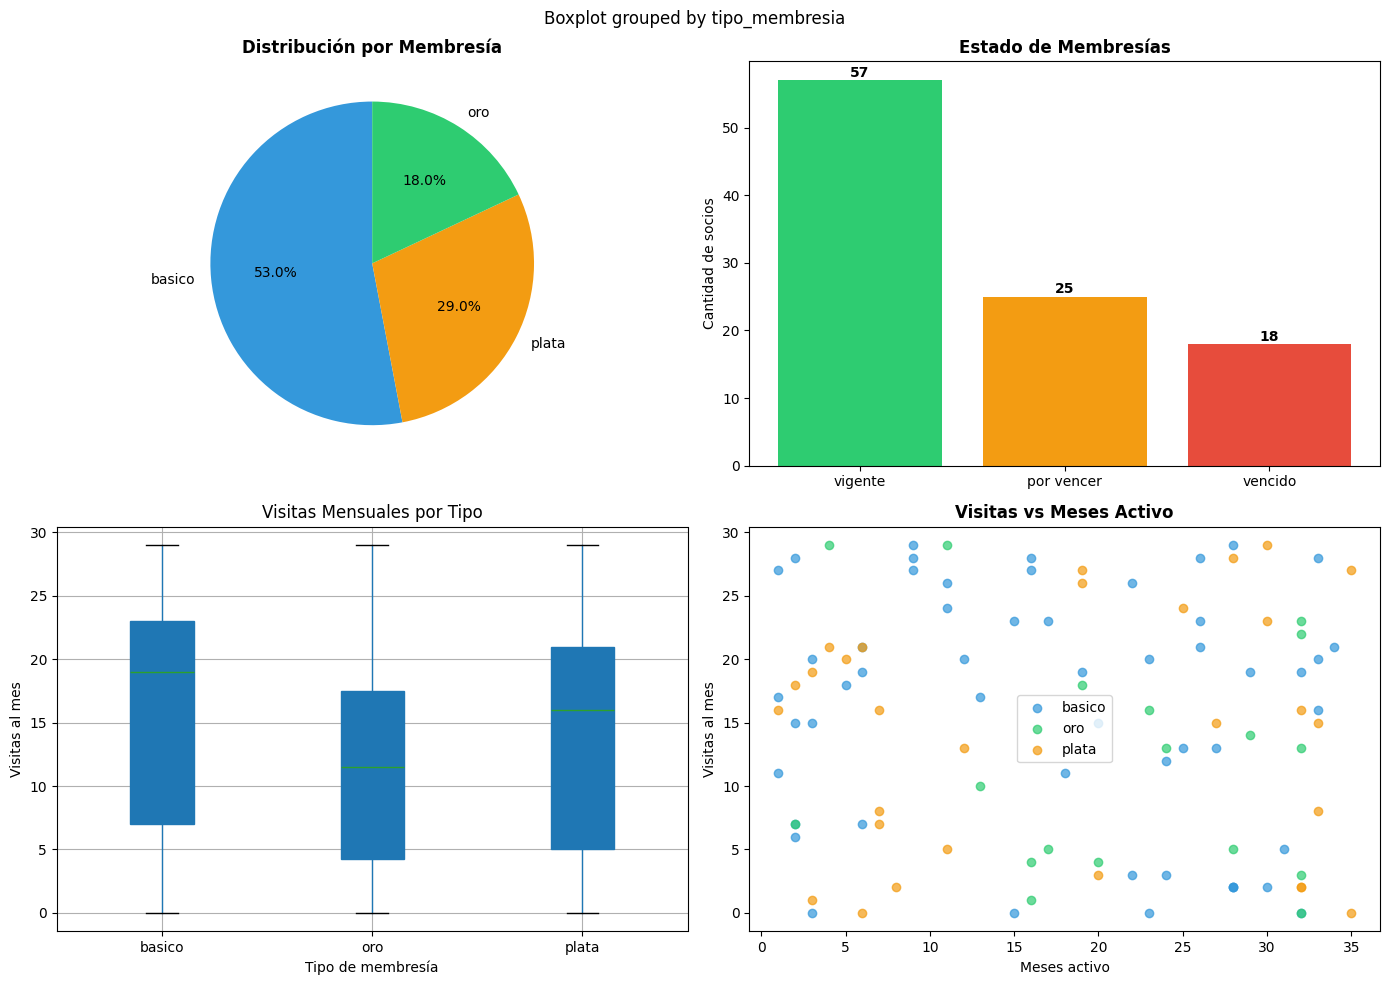

✅ Gráficos generados y guardados


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ClubManager — Dashboard de Análisis', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1 — Distribución por tipo
colores_tipo = ['#3498db', '#f39c12', '#2ecc71']
conteo_tipo = df['tipo_membresia'].value_counts()
axes[0,0].pie(conteo_tipo, labels=conteo_tipo.index, colors=colores_tipo,
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribución por Membresía', fontweight='bold')

# Gráfico 2 — Estado de membresías
colores_estado = {'vigente':'#2ecc71', 'por vencer':'#f39c12', 'vencido':'#e74c3c'}
conteo_estado = df['estado'].value_counts()
bars = axes[0,1].bar(conteo_estado.index, conteo_estado.values,
                      color=[colores_estado[e] for e in conteo_estado.index])
axes[0,1].set_title('Estado de Membresías', fontweight='bold')
axes[0,1].set_ylabel('Cantidad de socios')
for bar, val in zip(bars, conteo_estado.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   str(val), ha='center', fontweight='bold')

# Gráfico 3 — Visitas por tipo
df.boxplot(column='visitas_mes', by='tipo_membresia', ax=axes[1,0],
           patch_artist=True)
axes[1,0].set_title('Visitas Mensuales por Tipo', fontweight='bold')
axes[1,0].set_xlabel('Tipo de membresía')
axes[1,0].set_ylabel('Visitas al mes')
plt.sca(axes[1,0])
plt.title('Visitas Mensuales por Tipo')

# Gráfico 4 — Visitas vs meses activo
colores_scatter = {'basico':'#3498db', 'plata':'#f39c12', 'oro':'#2ecc71'}
for tipo, grupo in df.groupby('tipo_membresia'):
    axes[1,1].scatter(grupo['meses_activo'], grupo['visitas_mes'],
                      c=colores_scatter[tipo], label=tipo, alpha=0.7)
axes[1,1].set_title('Visitas vs Meses Activo', fontweight='bold')
axes[1,1].set_xlabel('Meses activo')
axes[1,1].set_ylabel('Visitas al mes')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('dashboard_clubmanager.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráficos generados y guardados")

##Entrenamiento del modelo con TensorFlow
### Tarea: Crea y entrena modelos ML — Regresión lineal para predecir renovaciones

In [5]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"TensorFlow versión: {tf.__version__}")

# Features: visitas_mes y meses_activo → predecir días para vencer
X = df[['visitas_mes', 'meses_activo']].values
y = df['dias_para_vencer'].values

# Normalizar datos
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).flatten()

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"✅ Datos preparados")
print(f"   Entrenamiento: {len(X_train)} socios")
print(f"   Prueba:        {len(X_test)} socios")

TensorFlow versión: 2.20.0
✅ Datos preparados
   Entrenamiento: 80 socios
   Prueba:        20 socios


In [6]:
# Crear modelo de red neuronal
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,), name='capa_entrada'),
    tf.keras.layers.Dense(8,  activation='relu', name='capa_oculta'),
    tf.keras.layers.Dense(1,  name='capa_salida')
])

modelo.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modelo.summary()

# Entrenar
historial = modelo.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

print("✅ Modelo entrenado correctamente")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_entrada (Dense)            │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta (Dense)             │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

✅ Modelo entrenado correctamente


📊 Error promedio (MAE): 0.8757
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


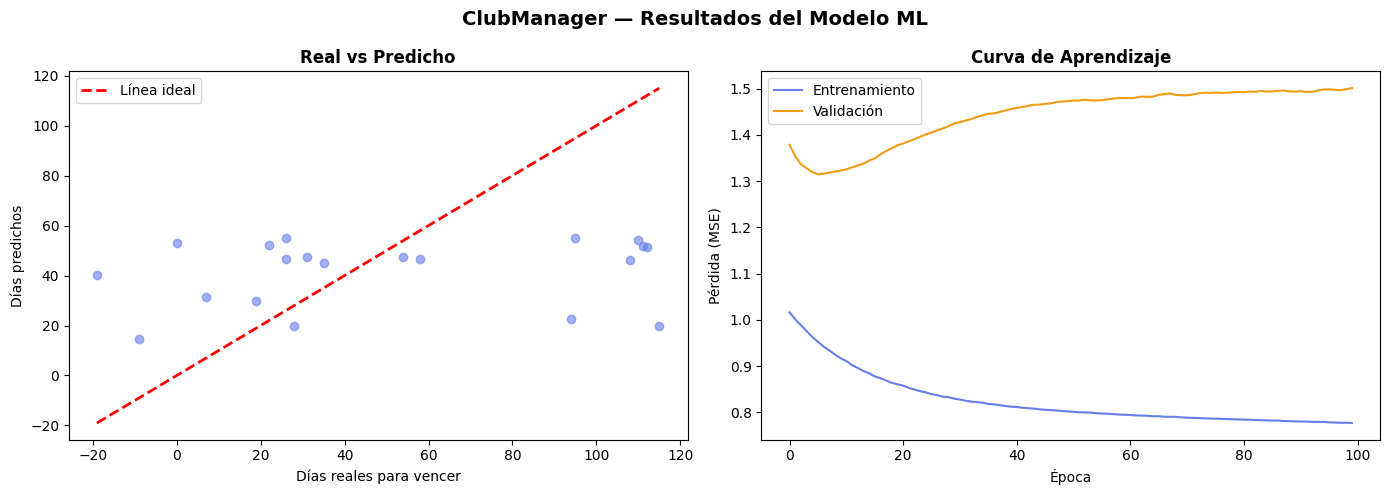

✅ Evaluación completada


In [7]:
# Evaluación
loss, mae = modelo.evaluate(X_test, y_test, verbose=0)
print(f"📊 Error promedio (MAE): {mae:.4f}")

# Predicciones
y_pred_scaled = modelo.predict(X_test).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_real = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ClubManager — Resultados del Modelo ML', fontsize=14, fontweight='bold')

# Gráfico 1 — Real vs Predicho
axes[0].scatter(y_real, y_pred, alpha=0.6, color='#667eea')
axes[0].plot([y_real.min(), y_real.max()],
             [y_real.min(), y_real.max()], 'r--', lw=2, label='Línea ideal')
axes[0].set_xlabel('Días reales para vencer')
axes[0].set_ylabel('Días predichos')
axes[0].set_title('Real vs Predicho', fontweight='bold')
axes[0].legend()

# Gráfico 2 — Pérdida durante entrenamiento
axes[1].plot(historial.history['loss'], label='Entrenamiento', color='#667eea')
axes[1].plot(historial.history['val_loss'], label='Validación', color='#f39c12')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida (MSE)')
axes[1].set_title('Curva de Aprendizaje', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('resultados_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluación completada")

In [8]:
import json

# Guardar modelo
modelo.save('modelo_clubmanager.h5')

# Guardar parámetros del scaler para usarlos en la web
scaler_params = {
    'mean_X': scaler_X.mean_.tolist(),
    'scale_X': scaler_X.scale_.tolist(),
    'mean_y': float(scaler_y.mean_[0]),
    'scale_y': float(scaler_y.scale_[0])
}

with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

print("✅ Modelo exportado: modelo_clubmanager.h5")
print("✅ Parámetros guardados: scaler_params.json")
print(f"\nParámetros del scaler:")
print(f"  Media X:  {scaler_params['mean_X']}")
print(f"  Escala X: {scaler_params['scale_X']}")
print(f"  Media y:  {scaler_params['mean_y']:.4f}")
print(f"  Escala y: {scaler_params['scale_y']:.4f}")

✅ Modelo exportado: modelo_clubmanager.h5
✅ Parámetros guardados: scaler_params.json

Parámetros del scaler:
  Media X:  [14.83, 18.14]
  Escala X: [9.444633396802653, 11.122068153001042]
  Media y:  45.6400
  Escala y: 42.7564
